In [3]:
import os
import json
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob

import tensorflow as tf
import keras
from keras import layers

import matplotlib.pyplot as plt

Installing open3d

In [4]:
!pip -q install open3d plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 127.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.0 MB/s eta 0:00:00


Creating list for 100 Ship OBJ files from ShapeNet database and initial parameters are defined.These are used for cropping and the training.

In [5]:
import os, glob
import numpy as np
import tensorflow as tf
import open3d as o3d

SHIP_FILES = []
BATCH_SIZE = 2
EPOCHS = 60
INITIAL_LR = 1e-3
NUMBER_OF_SHIPS =100

try:
    NUM_SAMPLE_POINTS
except NameError:
    NUM_SAMPLE_POINTS = 1024

# initial ship objects
#SHIPS_FILES = [
    #"model_normalized_ex3.obj",
    #"model_normalized_ex4.obj",
    #"model_normalized_ex5.obj",
    #"model_normalized_ex6.obj",
    #"model_normalized_ex7.obj",
    #"model_normalized_ex8.obj",
#]


for i in range(1,NUMBER_OF_SHIPS +1):
  SHIP_FILES.append(str(i)+".obj")
  print(SHIP_FILES)

SHIP_FILES = [p for p in SHIP_FILES if os.path.exists(p)]
print(f"[Ships]  OBJ-k: {len(SHIP_FILES)}")

# Others factors are set this list as mentioned in the "3.3.8 Data Balancing for Ship Point Clouds section"
FACTORS = tf.constant([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0], tf.float32)

# noise components using after cropping

noise_comp1= 0.02
noise_comp2= 0.05



LABELS_SHIP = ["ship", "others"]  # 0, 1


['1.obj']
['1.obj', '2.obj']
['1.obj', '2.obj', '3.obj']
['1.obj', '2.obj', '3.obj', '4.obj']
['1.obj', '2.obj', '3.obj', '4.obj', '5.obj']
['1.obj', '2.obj', '3.obj', '4.obj', '5.obj', '6.obj']
['1.obj', '2.obj', '3.obj', '4.obj', '5.obj', '6.obj', '7.obj']
['1.obj', '2.obj', '3.obj', '4.obj', '5.obj', '6.obj', '7.obj', '8.obj']
['1.obj', '2.obj', '3.obj', '4.obj', '5.obj', '6.obj', '7.obj', '8.obj', '9.obj']
['1.obj', '2.obj', '3.obj', '4.obj', '5.obj', '6.obj', '7.obj', '8.obj', '9.obj', '10.obj']
['1.obj', '2.obj', '3.obj', '4.obj', '5.obj', '6.obj', '7.obj', '8.obj', '9.obj', '10.obj', '11.obj']
['1.obj', '2.obj', '3.obj', '4.obj', '5.obj', '6.obj', '7.obj', '8.obj', '9.obj', '10.obj', '11.obj', '12.obj']
['1.obj', '2.obj', '3.obj', '4.obj', '5.obj', '6.obj', '7.obj', '8.obj', '9.obj', '10.obj', '11.obj', '12.obj', '13.obj']
['1.obj', '2.obj', '3.obj', '4.obj', '5.obj', '6.obj', '7.obj', '8.obj', '9.obj', '10.obj', '11.obj', '12.obj', '13.obj', '14.obj']
['1.obj', '2.obj', '3.obj'

This is the function for loading the ship OBJ files and sampling points

In [6]:
def read_points_from_obj(path: str, n_vis: int = 30000) -> np.ndarray:
    mesh = o3d.io.read_triangle_mesh(path)
    tris = np.asarray(mesh.triangles)
    if tris.size > 0:
        pcd = mesh.sample_points_uniformly(number_of_points=n_vis)
        return np.asarray(pcd.points, dtype=np.float32)


    #verts = []
    #with open(path, "r", encoding="utf-8", errors="ignore") as f:
        #for ln in f:
            #if ln.startswith("v "):
                #_, x, y, z = ln.split()[:4]
                #verts.append([float(x), float(y), float(z)])
    #if not verts:
        #raise ValueError(f"OBJ-ben nincs triangle/vertex: {path}")
    #return np.asarray(verts, dtype=np.float32)


Making the normalization and selecting 1024 point. I wrote about this fact in 3.3.7 chapter.

In [7]:
ship_point_clouds = []
ship_point_cloud_labels = []

rng = np.random.default_rng(42)

for path in SHIP_FILES:
    P = read_points_from_obj(path, n_vis=30000)
    if P.shape[0] == 0:
        continue

    # selecting 1024 points
    replace = P.shape[0] < NUM_SAMPLE_POINTS
    if replace:
        idx = rng.integers(0, P.shape[0], size=NUM_SAMPLE_POINTS, endpoint=False)
    else:
        idx = rng.choice(P.shape[0], size=NUM_SAMPLE_POINTS, replace=False)
    sampled = P[idx].astype(np.float32)

    # norm
    sampled = sampled - sampled.mean(0)
    sampled = sampled / (np.linalg.norm(sampled, axis=1).max() + 1e-9)


    labels_init = np.zeros((NUM_SAMPLE_POINTS, 2), dtype=np.float32)
    labels_init[:, 0] = 1.0

    # ship point clouds and labels
    ship_point_clouds.append(sampled)
    ship_point_cloud_labels.append(labels_init)

ship_point_clouds = np.asarray(ship_point_clouds, dtype=np.float32)
ship_point_cloud_labels = np.asarray(ship_point_cloud_labels, dtype=np.float32)
print("[Ships] arrays:", ship_point_clouds.shape, ship_point_cloud_labels.shape)


[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[Open3D IN

Visualizing ship point clouds (with 1024 points). In 3.1.3 Cropped Ship Dataset section I selected two examples regarding this block of code.

In [ ]:

def _axis_equal_3d(ax, P):

    P = np.asarray(P)
    max_range = np.ptp(P, axis=0).max()
    mid = P.mean(axis=0)
    ax.set_xlim(mid[0]-max_range/2, mid[0]+max_range/2)
    ax.set_ylim(mid[1]-max_range/2, mid[1]+max_range/2)
    ax.set_zlim(mid[2]-max_range/2, mid[2]+max_range/2)

def plot_point_cloud(points, labels=None, title=""):
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")

    if labels is None:
        ax.scatter(points[:,0], points[:,1], points[:,2], s=6, alpha=0.75)
    else:

        lbl = np.argmax(labels, axis=-1) if labels.ndim == 2 else labels
        for c in np.unique(lbl):
            mask = (lbl == c)
            ax.scatter(points[mask,0], points[mask,1], points[mask,2],
                       s=6, alpha=0.8, label=f"class {int(c)}")
        ax.legend(loc="upper right")

    _axis_equal_3d(ax, points)
    ax.set_title(title)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    plt.show()

def visualize_all_ships(P_list, L_list=None):
    n = len(P_list)
    for i in range(n):
        labels = None if L_list is None else L_list[i]
        plot_point_cloud(P_list[i], labels, title=f"Ship sample #{i}  (N={P_list[i].shape[0]})")

visualize_all_ships(ship_point_clouds, ship_point_cloud_labels)



Output hidden; open in https://colab.research.google.com to view.

This is the main code block , where ship cropping augmentation is made. Load_data, generate_dataset functions are also important.

In [9]:

#try:
    #X_all
    #Y_all
#except NameError:
    #X_all = np.asarray(ships_points, dtype=np.float32)
    #Y_all = np.asarray(ships_labels, dtype=np.float32)

X_all = np.asarray(ship_point_clouds, dtype=np.float32)
Y_all = np.asarray(ship_point_cloud_labels, dtype=np.float32)

import numpy as np
import tensorflow as tf
import random
import os

# random seed
GLOBAL_SEED = 42
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)

#assert X_all.ndim == 3 and X_all.shape[2] == 3,
#assert Y_all.ndim == 3,
#assert X_all.shape[:2] == Y_all.shape[:2],

# 3 way split parameters also defined here
NUM_SAMPLE_POINTS = X_all.shape[1]
NUM_CLASSES       = Y_all.shape[-1]
BATCH_SIZE        = 10
VAL_SPLIT         = 0.10
TEST_SPLIT        = 0.30
class_weight      = {}



def load_data(point_cloud_batch, label_cloud_batch):

    point_cloud_batch.set_shape([NUM_SAMPLE_POINTS, 3])
    label_cloud_batch.set_shape([NUM_SAMPLE_POINTS, NUM_CLASSES])
    return point_cloud_batch, label_cloud_batch

def augment(point_cloud_batch, label_cloud_batch):
    noise = tf.random.uniform(tf.shape(point_cloud_batch),
                              -0.001, 0.001, dtype=tf.float32)
    point_cloud_batch = point_cloud_batch + noise
    return point_cloud_batch, label_cloud_batch


# getting centroid, normal vector, getting distances, using a mask to keep one side of the ship
#(Section 3.1.3 )
def crop_point_cloud_ship(point_cloud_batch, label_cloud_batch):

    point_cloud_batch = tf.cast(point_cloud_batch, tf.float32)

    centroid = tf.reduce_mean(point_cloud_batch, axis=0)
    _scale   = tf.reduce_max(tf.norm(point_cloud_batch - centroid, axis=1)) + 1e-9
    centroid = centroid + tf.random.uniform([3], -0.1*_scale, 0.1*_scale, dtype=tf.float32)

    random_vector = tf.random.normal([3], dtype=tf.float32)
    plane_normal  = random_vector / (tf.norm(random_vector) + 1e-9)

    plane_point   = centroid + tf.random.uniform([3], -0.1*_scale, 0.1*_scale, dtype=tf.float32)

    point_to_plane_vector = point_cloud_batch - plane_point
    distances = tf.reduce_sum(point_to_plane_vector * plane_normal, axis=1)

    mask  = distances < 0.0
    mask2 = distances > 0.0
    ship_side_neg = tf.boolean_mask(point_cloud_batch, mask)
    ship_side_pos = tf.boolean_mask(point_cloud_batch, mask2)

    count_neg = tf.shape(ship_side_neg)[0]
    count_pos = tf.shape(ship_side_pos)[0]
    # keeping the bigger part
    keep_neg  = tf.greater_equal(count_neg, count_pos)

    cropped_point_cloud = tf.cond(keep_neg, lambda: ship_side_neg, lambda: ship_side_pos)
    ship_count = tf.where(keep_neg, count_neg, count_pos)

    k = tf.random.uniform((), 0, tf.shape(FACTORS)[0], dtype=tf.int32)
    others_factor = FACTORS[k]
    #others_count  = tf.maximum(1, tf.cast(tf.round(tf.cast(ship_count, tf.float32) * others_factor), tf.int32))
    # ship_count: selected ship points number
    # 1:1 ratio - didnt use the FACTORS as this setting didnt influence the segmentation with real ultrasound data
    others_count = tf.shape(cropped_point_cloud)[0]


    idx = tf.random.uniform((others_count,), 0, NUM_SAMPLE_POINTS, dtype=tf.int32)

    points   = tf.gather(point_cloud_batch, idx)

    #distance
    distance = tf.reduce_sum((points - plane_point) * plane_normal, axis=1, keepdims=True)
    proj = points - distance * plane_normal
    # projection onto the plane from q point cloud point I substract the vector which is defined with the distance and normal vector


    t = noise_comp1 * _scale
    n = noise_comp2 * _scale

    tang = tf.random.normal(tf.shape(proj), stddev=t, dtype=tf.float32)
    tang = tang - tf.reduce_sum(tang * plane_normal, axis=1, keepdims=True) * plane_normal

    scalar   = tf.random.normal((others_count, 1), stddev=n, dtype=tf.float32)
    # using plane-internal and a plane-external noise components to get mud/othre points
    others_point_cloud = proj + tang + scalar * plane_normal

    # concatentation
    points_cat = tf.concat([cropped_point_cloud, others_point_cloud], axis=0)
    labels_idx = tf.concat([
        tf.zeros((tf.shape(cropped_point_cloud)[0],), tf.int32),
        tf.ones((tf.shape(others_point_cloud)[0],),  tf.int32)
    ], axis=0)

    total_now = tf.shape(points_cat)[0]
    def sample_without_replacement():
        perm = tf.random.shuffle(tf.range(total_now))
        sel  = perm[:NUM_SAMPLE_POINTS]
        return tf.gather(points_cat, sel), tf.gather(labels_idx, sel)
    def sample_with_replacement():
        idx  = tf.random.uniform((NUM_SAMPLE_POINTS,), 0, total_now, dtype=tf.int32)
        return tf.gather(points_cat, idx), tf.gather(labels_idx, idx)

    train_points, train_labels_idx = tf.cond(total_now >= NUM_SAMPLE_POINTS,
                                             sample_without_replacement,
                                             sample_with_replacement)

    train_labels = tf.one_hot(train_labels_idx, depth=2, dtype=tf.float32)


    c = tf.reduce_mean(train_points, axis=0, keepdims=True)
    pc = train_points - c
    r = tf.reduce_max(tf.norm(pc, axis=1))
    train_points = pc / (r + 1e-9)

    return train_points, train_labels
    def when_zero():
        return (tf.zeros([NUM_SAMPLE_POINTS, 3], dtype=tf.float32),
                tf.zeros([NUM_SAMPLE_POINTS, num_classes], dtype=tf.float32))

    def when_nonzero():

        def sample_without_replacement():
            idx = tf.random.shuffle(tf.range(num_points, dtype=tf.int32))[:NUM_SAMPLE_POINTS]
            return tf.gather(cropped_point_cloud, idx), tf.gather(cropped_label_cloud, idx)

        def sample_with_replacement():
            idx = tf.random.uniform([NUM_SAMPLE_POINTS], 0, num_points, dtype=tf.int32)
            return tf.gather(cropped_point_cloud, idx), tf.gather(cropped_label_cloud, idx)

        cond = tf.greater_equal(num_points, NUM_SAMPLE_POINTS)
        return tf.cond(cond, sample_without_replacement, sample_with_replacement)

    return tf.cond(if_zero_pc, when_zero, when_nonzero)

def filter_empty_batches(point_cloud_batch, label_cloud_batch):
    # used for avoiding an error
    return tf.shape(point_cloud_batch)[0] > 0

# made a block diagram for airplanes, but it is similar also (In section 3.1.2)
def generate_dataset(point_clouds, label_clouds, is_training: bool):
    ds = tf.data.Dataset.from_tensor_slices(
        (tf.cast(point_clouds, tf.float32), tf.cast(label_clouds, tf.float32))
    )


    if is_training:
        ds = ds.shuffle(buffer_size=len(point_clouds), reshuffle_each_iteration=True)
        # used it to avoid an error, (mentioned in 3.3.7 section)
        ds = ds.repeat()


    ds = ds.map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(crop_point_cloud_ship, num_parallel_calls=tf.data.AUTOTUNE)

    if is_training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds



N = X_all.shape[0]
n_test = max(1, int(round(TEST_SPLIT * N)))
n_val  = max(1, int(round(VAL_SPLIT  * N)))


if n_test + n_val >= N:
    share = TEST_SPLIT / max(TEST_SPLIT + VAL_SPLIT, 1e-9)
    n_test = max(1, int(np.floor(share * (N - 1))))
    n_val  = max(1, (N - 1) - n_test)

n_train = N - n_test - n_val
#assert n_train >= 1,

perm = np.random.permutation(N)
test_idx  = perm[:n_test]
val_idx   = perm[n_test:n_test + n_val]
train_idx = perm[n_test + n_val:]

X_train, Y_train = X_all[train_idx], Y_all[train_idx]
X_val,   Y_val   = X_all[val_idx],   Y_all[val_idx]
X_test,  Y_test  = X_all[test_idx],  Y_all[test_idx]

#print(f"[Split counts] train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}")
#print("[Shapes] X:", X_all.shape, " Y:", Y_all.shape)

# validation, training and test sets
train_dataset = generate_dataset(X_train, Y_train, is_training=True)
val_dataset   = generate_dataset(X_val,   Y_val,   is_training=False)
test_dataset  = generate_dataset(X_test,  Y_test,  is_training=False)



print(f"[Split counts] train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}")


ship_ids = [os.path.basename(p) for p in SHIP_FILES]

ids_train = set(ship_ids[i] for i in train_idx)
ids_val   = set(ship_ids[i] for i in val_idx)
ids_test  = set(ship_ids[i] for i in test_idx)

# I shoud avoid Data Leakage
assert not (ids_train & ids_val),  " Leak: same ship between train and vaidation!"
assert not (ids_train & ids_test), " Leak: same ship between train and test!"
assert not (ids_val   & ids_test), "Leak: same ship between validation and test!"

print("OK: noleakage.")

print("TRAIN:", sorted(ids_train))
print("VAL  :", sorted(ids_val))
print("TEST :", sorted(ids_test))


total_training_examples = X_train.shape[0]
print("total_training_examples")
print(total_training_examples)
print("Train Dataset:", train_dataset)
print("Validation Dataset:", val_dataset)
print("Test Dataset:", test_dataset)

def print_class_distribution(dataset, name, compute_weights=False):
    all_labels = []
    for _, lbl_batch in dataset:
        li = np.argmax(lbl_batch.numpy(), axis=-1)
        all_labels.extend(li.ravel())
    unique, counts = np.unique(all_labels, return_counts=True)
    dist = dict(zip(unique, counts))
    print(f"{name} class distribution (0=ship,1=others):", dist)

    if compute_weights:
        total = counts.sum()
        cw = {}
        for cls, cnt in zip(unique, counts):
            cw[int(cls)] = float((1.0 / max(cnt, 1)) * (total / len(unique)))
        return cw
    return None

#cw = print_class_distribution(train_dataset, "Train", compute_weights=True)
#_  = print_class_distribution(val_dataset,   "Val",   compute_weights=False)
#_  = print_class_distribution(test_dataset,  "Test",  compute_weights=False)

#if cw is not None:
    #class_weight = cw
    #print("Class weights:", class_weight)


def plot_point_cloud(points, labels, title="Point Cloud"):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    labels = np.asarray(labels)
    for lab in np.unique(labels):
        mask = labels == lab
        pts  = points[mask]
        ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=5, alpha=0.6, label=f"class {int(lab)}")
    ax.set_title(title)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.legend()
    plt.show()

def visualize_dataset_all(dataset, name):
    print(f"\n--- Visualize {name} ---")
    count = 0

    for pc, lbl in dataset.unbatch():
        pc_np  = pc.numpy()
        lbl_np = np.argmax(lbl.numpy(), axis=-1)
        plot_point_cloud(pc_np, lbl_np, title=f"{name} sample #{count}")
        count += 1
    print(f"{name}: {count} minta megjelenítve.")

#visualize_dataset_all(train_dataset, "Train")
#visualize_dataset_all(train_dataset, "Train")
#visualize_dataset_all(val_dataset,   "Val")
#visualize_dataset_all(test_dataset,  "Test")


[Split counts] train: 60, val: 10, test: 30
OK: noleakage.
TRAIN: ['100.obj', '14.obj', '15.obj', '18.obj', '2.obj', '20.obj', '21.obj', '22.obj', '24.obj', '25.obj', '26.obj', '28.obj', '3.obj', '30.obj', '33.obj', '35.obj', '37.obj', '38.obj', '39.obj', '4.obj', '42.obj', '44.obj', '47.obj', '49.obj', '50.obj', '51.obj', '52.obj', '53.obj', '55.obj', '57.obj', '58.obj', '59.obj', '60.obj', '61.obj', '62.obj', '63.obj', '64.obj', '65.obj', '68.obj', '69.obj', '7.obj', '72.obj', '75.obj', '76.obj', '79.obj', '8.obj', '80.obj', '82.obj', '83.obj', '85.obj', '87.obj', '88.obj', '9.obj', '90.obj', '92.obj', '93.obj', '95.obj', '96.obj', '98.obj', '99.obj']
VAL  : ['12.obj', '17.obj', '29.obj', '36.obj', '48.obj', '6.obj', '66.obj', '67.obj', '86.obj', '94.obj']
TEST : ['1.obj', '10.obj', '11.obj', '13.obj', '16.obj', '19.obj', '23.obj', '27.obj', '31.obj', '32.obj', '34.obj', '40.obj', '41.obj', '43.obj', '45.obj', '46.obj', '5.obj', '54.obj', '56.obj', '70.obj', '71.obj', '73.obj', '74.o

## PointNet model

The figure below depicts the internals of the PointNet model family:

![](https://i.imgur.com/qFLNw5L.png)

Given that PointNet is meant to consume an ***unordered set*** of coordinates as its input data,
its architecture needs to match the following characteristic properties
of point cloud data:

### Permutation invariance

Given the unstructured nature of point cloud data, a scan made up of `n` points has `n!`
permutations. The subsequent data processing must be invariant to the different
representations. In order to make PointNet invariant to input permutations, we use a
symmetric function (such as max-pooling) once the `n` input points are mapped to
higher-dimensional space. The result is a **global feature vector** that aims to capture
an aggregate signature of the `n` input points. The global feature vector is used alongside
local point features for segmentation.

![](https://i.imgur.com/0mrvvjb.png)

### Transformation invariance

Segmentation outputs should be unchanged if the object undergoes certain transformations,
such as translation or scaling. For a given input point cloud, we apply an appropriate
rigid or affine transformation to achieve pose normalization. Because each of the `n` input
points are represented as a vector and are mapped to the embedding spaces independently,
applying a geometric transformation simply amounts to matrix multiplying each point with
a transformation matrix. This is motivated by the concept of
[Spatial Transformer Networks](https://arxiv.org/abs/1506.02025).

The operations comprising the T-Net are motivated by the higher-level architecture of
PointNet. MLPs (or fully-connected layers) are used to map the input points independently
and identically to a higher-dimensional space; max-pooling is used to encode a global
feature vector whose dimensionality is then reduced with fully-connected layers. The
input-dependent features at the final fully-connected layer are then combined with
globally trainable weights and biases, resulting in a 3-by-3 transformation matrix.

![](https://i.imgur.com/aEj3GYi.png)

### Point interactions

The interaction between neighboring points often carries useful information (i.e., a
single point should not be treated in isolation). Whereas classification need only make
use of global features, segmentation must be able to leverage local point features along
with global point features.


**Note**: The figures presented in this section have been taken from the
[original paper](https://arxiv.org/abs/1612.00593).

Now that we know the pieces that compose the PointNet model, we can implement the model.
We start by implementing the basic blocks i.e., the convolutional block and the multi-layer
perceptron block.

In [10]:

def conv_block(x, filters, name):
    x = layers.Conv1D(filters, kernel_size=1, padding="valid", name=f"{name}_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_batch_norm")(x)
    return layers.Activation("relu", name=f"{name}_relu")(x)


def mlp_block(x, filters, name):
    x = layers.Dense(filters, name=f"{name}_dense")(x)
    x = layers.BatchNormalization(name=f"{name}_batch_norm")(x)
    return layers.Activation("relu", name=f"{name}_relu")(x)


We implement a regularizer (taken from
[this example](https://keras.io/examples/vision/pointnet/#build-a-model))
to enforce orthogonality in the feature space. This is needed to ensure
that the magnitudes of the transformed features do not vary too much.

In [11]:

class OrthogonalRegularizer(keras.regularizers.Regularizer):
    """Reference: https://keras.io/examples/vision/pointnet/#build-a-model"""

    def __init__(self, num_features, l2reg=0.001):
        self.num_features = num_features
        self.l2reg = l2reg
        self.identity = keras.ops.eye(num_features)

    def __call__(self, x):
        x = keras.ops.reshape(x, (-1, self.num_features, self.num_features))
        xxt = keras.ops.tensordot(x, x, axes=(2, 2))
        xxt = keras.ops.reshape(xxt, (-1, self.num_features, self.num_features))
        return keras.ops.sum(self.l2reg * keras.ops.square(xxt - self.identity))

    def get_config(self):
        config = super().get_config()
        config.update({"num_features": self.num_features, "l2reg_strength": self.l2reg})
        return config


The next piece is the transformation network which we explained earlier.

In [12]:

def transformation_net(inputs, num_features, name):
    """
    Reference: https://keras.io/examples/vision/pointnet/#build-a-model.

    The `filters` values come from the original paper:
    https://arxiv.org/abs/1612.00593.
    """
    x = conv_block(inputs, filters=64, name=f"{name}_1")
    x = conv_block(x, filters=128, name=f"{name}_2")
    x = conv_block(x, filters=1024, name=f"{name}_3")
    x = layers.GlobalMaxPooling1D()(x)
    x = mlp_block(x, filters=512, name=f"{name}_1_1")
    x = mlp_block(x, filters=256, name=f"{name}_2_1")
    return layers.Dense(
        num_features * num_features,
        kernel_initializer="zeros",
        bias_initializer=keras.initializers.Constant(np.eye(num_features).flatten()),
        activity_regularizer=OrthogonalRegularizer(num_features),
        name=f"{name}_final",
    )(x)


def transformation_block(inputs, num_features, name):
    transformed_features = transformation_net(inputs, num_features, name=name)
    transformed_features = layers.Reshape((num_features, num_features))(
        transformed_features
    )
    return layers.Dot(axes=(2, 1), name=f"{name}_mm")([inputs, transformed_features])


Finally, we piece the above blocks together and implement the segmentation model.

In [13]:

def get_shape_segmentation_model(num_points, num_classes):
    input_points = keras.Input(shape=(None, 3))

    # PointNet Classification Network.
    transformed_inputs = transformation_block(
        input_points, num_features=3, name="input_transformation_block"
    )
    features_64 = conv_block(transformed_inputs, filters=64, name="features_64")
    features_128_1 = conv_block(features_64, filters=128, name="features_128_1")
    features_128_2 = conv_block(features_128_1, filters=128, name="features_128_2")
    transformed_features = transformation_block(
        features_128_2, num_features=128, name="transformed_features"
    )
    features_512 = conv_block(transformed_features, filters=512, name="features_512")
    features_2048 = conv_block(features_512, filters=2048, name="pre_maxpool_block")
    global_features = layers.MaxPool1D(pool_size=num_points, name="global_features")(
        features_2048
    )
    global_features = keras.ops.tile(global_features, [1, num_points, 1])

    # Segmentation head.
    segmentation_input = layers.Concatenate(name="segmentation_input")(
        [
            features_64,
            features_128_1,
            features_128_2,
            transformed_features,
            features_512,
            global_features,
        ]
    )
    segmentation_features = conv_block(
        segmentation_input, filters=128, name="segmentation_features"
    )
    outputs = layers.Conv1D(
        num_classes, kernel_size=1, activation="softmax", name="segmentation_head"
    )(segmentation_features)
    return keras.Model(input_points, outputs)


## Instantiate the model

In [14]:
#ha biba -> update keras


x, y = next(iter(train_dataset))

num_points = x.shape[1]
num_classes = y.shape[-1]
segmentation_model = get_shape_segmentation_model(num_points, num_classes)
segmentation_model.summary()
print("NUM CLASSES")
print(num_classes)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, None, 64)  │        256 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, None, 64)  │        256 │ input_transforma… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, None, 64)  │          0 │ input_transforma… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, None, 128) │      8,320 │ input_transforma… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, None, 128) │        512 │ input_transforma… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, None, 128) │          0 │ input_transforma… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, None,      │    132,096 │ input_transforma… │
│ (Conv1D)            │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, None,      │      4,096 │ input_transforma… │
│ (BatchNormalizatio… │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, None,      │          0 │ input_transforma… │
│ (Activation)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1024)      │          0 │ input_transforma… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, 512)       │    524,800 │ global_max_pooli… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, 512)       │      2,048 │ input_transforma… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, 512)       │          0 │ input_transforma… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, 256)       │    131,328 │ input_transforma… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, 256)       │      1,024 │ input_transforma… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_transformati… │ (None, 256)       │          0 │ input_transforma

 Total params: 7,369,675 (28.11 MB)

 Trainable params: 7,355,723 (28.06 MB)

 Non-trainable params: 13,952 (54.50 KB)

NUM CLASSES
2


## Training

For the training the authors recommend using a learning rate schedule that decays the
initial learning rate by half every 20 epochs.

Steps per epoch: 200.
Total training steps: 12000.


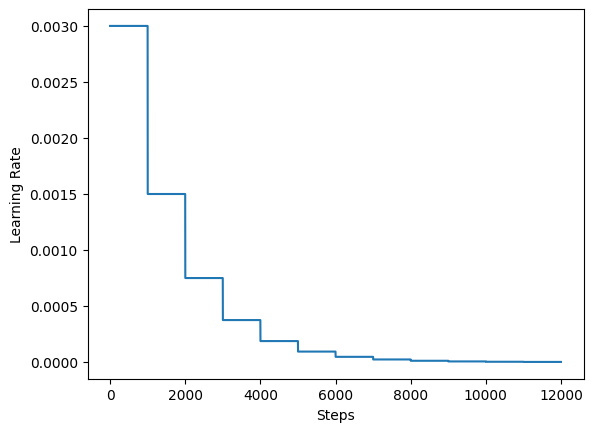

In [15]:

#steps_per_epoch = total_training_examples // BATCH_SIZE

steps_per_epoch = max(200, (total_training_examples * 4) // BATCH_SIZE)
total_training_steps = steps_per_epoch * EPOCHS
print(f"Steps per epoch: {steps_per_epoch}.")
print(f"Total training steps: {total_training_steps}.")

lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.003,
    decay_steps=steps_per_epoch * 5,
    decay_rate=0.5,
    staircase=True,
)

steps = range(total_training_steps)
lrs = [lr_schedule(step) for step in steps]

plt.plot(lrs)
plt.xlabel("Steps")
plt.ylabel("Learning Rate")
plt.show()

This is the training block of code

In [16]:
# Convert the class_weight dictionary to a list
#alpha = [class_weight[i] * 0.5 for i in range(len(class_weight))]
#


EPOCH_VAR = tf.Variable(0, dtype=tf.int32)

class SetEpochCallback(keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        EPOCH_VAR.assign(int(epoch))

def run_experiment(epochs):
    segmentation_model = get_shape_segmentation_model(num_points, num_classes)
    #segmentation_model.load_weights('model_weights_szept26good_split60-10-30_around80%_on_test.weights.h5')
    segmentation_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
        loss=keras.losses.CategoricalCrossentropy(),
        #loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=1.0, alpha=alpha),
        metrics=["accuracy"],
    )

    checkpoint_filepath = "checkpoint.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
    )

    history = segmentation_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        callbacks=[SetEpochCallback(), checkpoint_callback],
        #class_weight=class_weight
        #class weight parameter

    )

    segmentation_model.load_weights(checkpoint_filepath)
    return segmentation_model, history

#segmentation_model.save()
#segmentation_model.save_weights()
segmentation_model, history = run_experiment(epochs=EPOCHS)

Epoch 1/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.5322 - loss: 172.1029 - val_accuracy: 0.5081 - val_loss: 237.1194
Epoch 2/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.5746 - loss: 13.6916 - val_accuracy: 0.5043 - val_loss: 16.1333
Epoch 3/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.5838 - loss: 13.4780 - val_accuracy: 0.5011 - val_loss: 13.5876
Epoch 4/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.5937 - loss: 13.3874 - val_accuracy: 0.5251 - val_loss: 13.4161
Epoch 5/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.6091 - loss: 13.3535 - val_accuracy: 0.5321 - val_loss: 13.3938
Epoch 6/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.6347 - loss: 13.3059 - val_accuracy: 0.6270 - val_loss: 13.3277
Epoch 7/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.6361 - loss: 13.3047 - val_accuracy: 0.5239 - val_loss: 13.4179
Epoch 8/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.6611 -

## Visualizing Training and Validation loss and accuracy

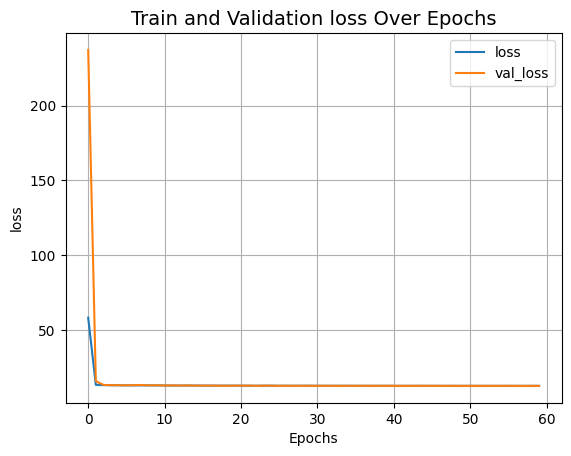

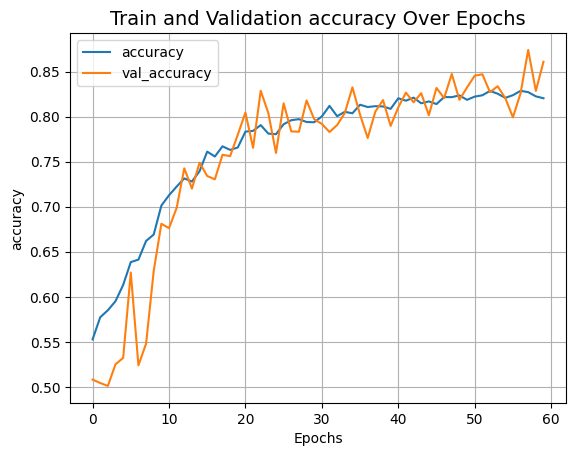

In [19]:

def plot_result(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_result("loss")
plot_result("accuracy")

Confusion Matrix, written in 3.3.10



Point cloud shape: (10, 1024, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
pred shape
(10, 1024, 2)
pred
[[[7.76903212e-01 2.23096788e-01]
  [2.46573344e-01 7.53426671e-01]
  [9.75275114e-02 9.02472496e-01]
  ...
  [9.85288680e-01 1.47113325e-02]
  [1.23583682e-01 8.76416266e-01]
  [1.74295790e-02 9.82570529e-01]]

 [[9.86618638e-01 1.33813042e-02]
  [2.87911862e-01 7.12088168e-01]
  [9.00769353e-01 9.92307290e-02]
  ...
  [8.16949964e-01 1.83050036e-01]
  [3.71527262e-02 9.62847352e-01]
  [9.85395253e-01 1.46047622e-02]]

 [[1.02514416e-01 8.97485554e-01]
  [9.50241864e-01 4.97581139e-02]
  [4.11826581e-01 5.88173449e-01]
  ...
  [5.94392836e-01 4.05607104e-01]
  [2.29124516e-01 7.70875454e-01]
  [9.30955172e-01 6.90448582e-02]]

 ...

 [[4.77409095e-01 5.22590935e-01]
  [4.00276840e-01 5.99723101e-01]
  [4.20284420e-01 5.79715550e-01]
  ...
  [5.82336724e-01 4.17663306e-01]
  [4.16933239e-01 5.83066761e-01]
  [5.07928550e-01 4.92071480e-01]]

 [[9.20076147e-02 9.07992482e-01]
  [4.612936

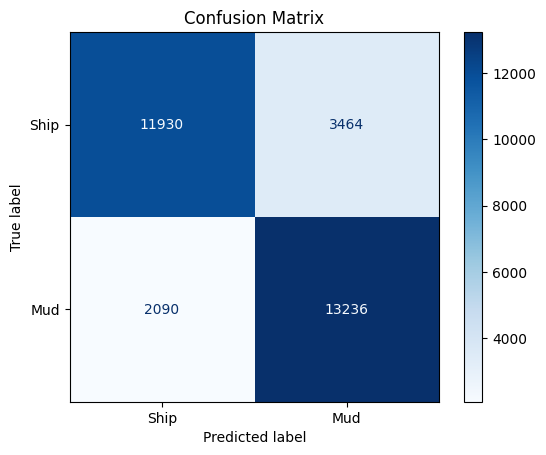

Test accuracy: 81.92%
              precision    recall  f1-score   support

        Ship       0.85      0.77      0.81     15394
         Mud       0.79      0.86      0.83     15326

    accuracy                           0.82     30720
   macro avg       0.82      0.82      0.82     30720
weighted avg       0.82      0.82      0.82     30720

Ship label accurac: 77.50%
Mud label accurac: 86.36%

Average accuracy across labels: 81.93%


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import tensorflow as tf


#class_names = ['Wing', 'Body', 'Tail', 'Engine', 'None']
#class_names = LABELS
class_names = ["Ship", "Mud"]


flattened_true_labels = []
flattened_pred_labels = []

# Iterate over the test dataset containing cropped ships
for point_cloud, label in test_dataset:
    print(f"Point cloud shape: {point_cloud.shape}")


    if isinstance(point_cloud, tf.Tensor):
        point_cloud = point_cloud.numpy()

    # Model predictions
    pred = segmentation_model.predict(point_cloud)
    print("pred shape")
    print(pred.shape)
    print("pred")
    print(pred)

    pred = pred.reshape(-1, 2).argmax(axis=-1)
    print("pred reshape utan")
    print(pred.shape)
    print(pred)
    #


    label = tf.reshape(label, (-1, 2)).numpy().argmax(axis=-1)
    #label = tf.reshape(label, (-1, 5)).numpy()
    #after reshape the dimension will be (32768, 5)
    # with the help of reshape the dimension 5 will be kept and python calculates the number of dimensions to get from 3D to 2D!
    # argmax looking for the biggest value in the last within the last dimension
    # we need to do it in case of label and pred as well. Label contains one-hot encoded data.


    print(f"Predictions (flattened): {pred[:10]}")
    print(f"True labels (flattened): {label[:10]}")

    num_points = len(pred)
    print("num points")
    print(num_points)
    #flattened_pred_labels.extend(pred[:num_points])
    #flattened_true_labels.extend(label[:num_points])



    flattened_pred_labels.extend(pred)
    flattened_true_labels.extend(label)


y_true = np.array(flattened_true_labels)
y_pred = np.array(flattened_pred_labels)


print("y_true")
print(y_true)
#print(y_true.shape)


print("y_pred")
print(y_pred.shape)

print(f"Total number of true labels: {len(y_true)}")
print(f"Total number of predicted labels: {len(y_pred)}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

success_rates = []
# Debugging output for the confusion matrix
print("Confusion Matrix:")
print(cm)

# Confusion matrix display with class names
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)

accuracy = np.sum(y_true == y_pred) / len(y_true) * 100
print(f"Test accuracy: {accuracy:.2f}%")
print(report)

for i, class_name in enumerate(class_names):
    #print("i")
    #print(i)
    true_class_indices = (y_true == i)  # checking for indices
    correct_predictions = np.sum((y_true == i) & (y_pred == i))
    total_true_class = np.sum(true_class_indices)

    if total_true_class > 0:
        success_rate = correct_predictions / total_true_class * 100
        success_rates.append(success_rate)
        print(f"{class_name} label accurac: {success_rate:.2f}%")
    else:
        print(f"{class_name} címkéhez nincs valódi adat.")

average_accuracy = np.mean(success_rates)
print(f"\nAverage accuracy across labels: {average_accuracy:.2f}%")


PointNet Predictions and Real labels of points, (written in 4.3 section)

In [22]:

def plot_point_cloud(points, labels=None, title="", class_names=None):
    points = np.asarray(points)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    if labels is None:
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=5)
    else:
        labels = np.asarray(labels).reshape(-1)
        if class_names is None:
            class_names = [f"Class {i}" for i in np.unique(labels)]

        for c in np.unique(labels):
            mask = (labels == c)
            ax.scatter(
                points[mask, 0],
                points[mask, 1],
                points[mask, 2],
                s=5,
                label=class_names[c] if c < len(class_names) else f"Class {c}",
            )
        ax.legend()

    ax.set_title(title)
    plt.show()





class_names = ["Ship", "Mud"]

flattened_true_labels = []
flattened_pred_labels = []

# Iterate on test dataset
for point_cloud_batch, label_cloud_batch in test_dataset:
    num_samples = tf.shape(point_cloud_batch)[0]

    # Selecting random point clouds to visualize
    random_indices = random.sample(range(num_samples), min(5, num_samples))

    for index in random_indices:

        point_cloud = point_cloud_batch[index].numpy()
        label = label_cloud_batch[index].numpy()


        point_cloud_input = np.expand_dims(point_cloud, axis=0)

        # Model predictions using predict() function
        pred = segmentation_model.predict(point_cloud_input)
        pred_labels = np.argmax(pred, axis=-1).squeeze()
        true_labels = np.argmax(label, axis=-1)


        flattened_true_labels.extend(true_labels.flatten())
        flattened_pred_labels.extend(pred_labels.flatten())

        #vizualisation
        plot_point_cloud(point_cloud, labels=true_labels, title="Point Cloud - Real", class_names=class_names)
        plot_point_cloud(point_cloud, labels=pred_labels, title="Point Cloud- Predicted", class_names=class_names)

# Convert to numpy arrays for confusion matrix calculation
y_true = np.array(flattened_true_labels)
y_pred = np.array(flattened_pred_labels)

# Confusion matrix calculation and display
#cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
#print("Confusion Matrix:")
#print(cm)

# Plot confusion matrix
#disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
#disp.plot(cmap=plt.cm.Blues)
#plt.title('Confusion Matrix')
#plt.show()

# Classification report
#report = classification_report(y_true, y_pred, target_names=class_names)
#accuracy = np.sum(y_true == y_pred) / len(y_true) * 100
#print(f"Helyes találati arány: {accuracy:.2f}%")
##print(report)

# Per-class success rate
for i, class_name in enumerate(class_names):
    true_class_indices = (y_true == i)
    correct_predictions = np.sum((y_true == i) & (y_pred == i))
    total_true_class = np.sum(true_class_indices)
    if total_true_class > 0:
        success_rate = correct_predictions / total_true_class * 100
        #print(f"{class_name} succes rate: {success_rate:.2f}%")
    else:
        print(f"{class_name} no real data for label.")


Output hidden; open in https://colab.research.google.com to view.

KNN based method for all the points from real data


debugging_v1.ply,
cropped_output3pipelined_new_ship_nov27_5(legjobb).ply, cropped_output3pipelined_okt17_jo.ply
are good point clouds with less noise, therefore it is worth to try segmentation with them)

In [ ]:

import os, numpy as np, torch



# segmentation_model = tf.keras.models.load_model(".../your_checkpoint.h5")

#FILE_PATH    = "debugging_v1.ply"
#FILE_PATH    = "robot_motion_pointcloud_okt.06_02.0.ply"
#FILE_PATH    = "cropped_output3pipelined.ply"
#FILE_PATH = "cropped_output3pipelined_new_ship_nov27_5(legjobb).ply"
#FILE_PATH= "cropped_output3pipelined_okt17_jo.ply"
FILE_PATH = "cropped_output3pipelined_new_ship_nov27_5(legjobb).ply"
CLASS_NAMES  = ["ship", "mud"]
SAVE_HTML    = True
HTML_PATH    = "segmentation_view(more_than_1024_points).html"
VOXEL_SIZE   = 0.01
KNN_K        = 3
SMOOTH       = True


# loading points
def load_ply_points(path: str) -> np.ndarray:
    try:
        import open3d as o3d
    except ImportError as e:
        raise RuntimeError("Need open3d: pip install open3d") from e
    pcd = o3d.io.read_point_cloud(path)
    if pcd.is_empty():
        raise ValueError(f"Empty PLY: {path}")
    return np.asarray(pcd.points, dtype=np.float32)

points_full = load_ply_points(FILE_PATH)
M = points_full.shape[0]
print(f"Loaded: {FILE_PATH}  |  Points: {M:,}")

def voxel_downsample_with_index(xyz: np.ndarray, voxel_size=0.01):
    if xyz.size == 0:
        return xyz, np.empty((0,), dtype=np.int64)
    v = np.floor(xyz / voxel_size).astype(np.int64)
    key = v[:,0] * 73856093 ^ v[:,1] * 19349663 ^ v[:,2] * 83492791
    _, idx = np.unique(key, return_index=True)
    return xyz[idx], idx

# FPS
@torch.no_grad()
def fps_idx(points_sub: np.ndarray, m=1024, device="cpu"):
    S = points_sub.shape[0]
    if S <= m:
        base = np.arange(S)
        extra = np.random.randint(0, S, size=m-S) if S < m else np.array([], dtype=int)
        return np.concatenate([base, extra])
    P = torch.from_numpy(points_sub).float().to(device)
    chosen = torch.zeros(m, dtype=torch.long, device=device)
    farthest = torch.randint(0, S, (1,), device=device)
    distances = torch.full((S,), 1e10, device=device)
    for i in range(m):
        chosen[i] = farthest
        centroid = P[farthest, :].view(1,3)
        dist = torch.sum((P - centroid) ** 2, dim=1)
        distances = torch.minimum(distances, dist)
        farthest = torch.argmax(distances)
    return chosen.cpu().numpy()

def normalize_unit_sphere(xyz):
    c = xyz.mean(axis=0, keepdims=True)
    pc = xyz - c
    scale = np.linalg.norm(pc, axis=1).max() + 1e-9
    return pc/scale, c, scale

def softmax_rows_np(logits):
    x = logits - logits.max(axis=1, keepdims=True)
    e = np.exp(x)
    return e / (e.sum(axis=1, keepdims=True) + 1e-12)

# Selecting k neighbors from all the points using fit and kneighbors functions
def project_back_knn(all_xyz, sampled_xyz, sampled_probs, k=3, mode="soft"):
    from sklearn.neighbors import NearestNeighbors
    nbrs = NearestNeighbors(n_neighbors=k, algorithm='kd_tree').fit(sampled_xyz)
    idx = nbrs.kneighbors(all_xyz, return_distance=False)
    print("idxshape")
    print(idx.shape)
    if mode == "soft":
        probs = sampled_probs[idx].mean(axis=1)
        labels = probs.argmax(axis=1).astype(int)
        return labels, probs


def knn_conf_smooth(all_xyz, probs_all, k=16, conf_min=0.55):
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=k, algorithm='kd_tree').fit(all_xyz)
    idx = nn.kneighbors(return_distance=False)
    conf = probs_all.max(axis=1, keepdims=True)
    w = np.clip(conf, 0.1, 1.0)
    votes = np.zeros_like(probs_all)
    for i in range(all_xyz.shape[0]):
        neigh = idx[i]
        votes[i] = (probs_all[neigh] * w[neigh]).mean(axis=0)
    mask = conf.squeeze() < conf_min
    out = probs_all.copy()
    out[mask] = votes[mask]
    labels = out.argmax(axis=1).astype(int)
    return labels, out

#doing FPS and predictions, voxeldownsampling
def predict_from_1024(all_points_Mx3,
                      model,
                      class_count,
                      voxel_size=0.01,
                      device="cpu",
                      knn_k=3,
                      smooth=False):
    sub_pts, sub_keep = voxel_downsample_with_index(all_points_Mx3, voxel_size=voxel_size)
    #sub_pts = all_points_Mx3
    #sub_keep = np.arange(sub_pts.shape[0])
    idx_sub = fps_idx(sub_pts, m=1024, device=device)
    idx_1024 = sub_keep[idx_sub]
    sampled_xyz_orig = all_points_Mx3[idx_1024]
    pts_norm, _, _ = normalize_unit_sphere(sampled_xyz_orig)
    x = np.expand_dims(pts_norm.astype(np.float32), 0)
    logits = model.predict(x, verbose=0)
    if logits.ndim == 3:
        probs_1024 = softmax_rows_np(logits[0])
    else:
        labs = logits[0].astype(int)
        probs_1024 = np.zeros((pts_norm.shape[0], class_count), np.float32)
        probs_1024[np.arange(pts_norm.shape[0]), labs] = 1.0
    labels_all, probs_all = project_back_knn(
        all_xyz=all_points_Mx3,
        sampled_xyz=sampled_xyz_orig,
        sampled_probs=probs_1024,
        k=knn_k,
        mode="soft"
    )
    if smooth:
        labels_all, probs_all = knn_conf_smooth(all_points_Mx3, probs_all, k=16, conf_min=0.55)
    return labels_all, probs_all, idx_1024


C = len(CLASS_NAMES)
final_labels, probs_all, idx_1024 = predict_from_1024(
    all_points_Mx3=points_full,
    model=segmentation_model,
    class_count=C,
    voxel_size=VOXEL_SIZE,
    device="cpu",
    knn_k=KNN_K,
    smooth=SMOOTH
)
print("Distribution:", {CLASS_NAMES[c]: int((final_labels==c).sum()) for c in range(C)})

# visualiation
def visualize_plotly(points, labels, class_names, save_html=None, max_points=120_000):
    import numpy as np, plotly.graph_objects as go
    try:
        import plotly.express as px
        palette = px.colors.qualitative.Safe
    except Exception:
        palette = ["#636EFA","#EF553B","#00CC96","#AB63FA","#FFA15A",
                   "#19D3F3","#FF6692","#B6E880","#FF97FF","#FECB52"]

    N = points.shape[0]
    if N > max_points:
        sel = []
        for cid in range(len(class_names)):
            idx = np.where(labels==cid)[0]
            q = int(round(idx.size / N * max_points))
            if q>0:
                sel.append(np.random.choice(idx, size=min(q, idx.size), replace=False))
        if len(sel):
            sel = np.concatenate(sel)
        else:
            sel = np.random.choice(N, size=max_points, replace=False)
        P = points[sel]; L = labels[sel]
    else:
        P = points; L = labels

    fig = go.Figure()
    for cid, name in enumerate(class_names):
        m = (L==cid)
        if not np.any(m): continue
        fig.add_trace(go.Scatter3d(
            x=P[m,0], y=P[m,1], z=P[m,2],
            mode="markers",
            marker=dict(size=2, color=palette[cid % len(palette)]),
            name=name
        ))
    title = f"Point Cloud Segmentation ({os.path.basename(FILE_PATH)})"
    fig.update_layout(
        title=title, legend_title_text="Classes",
        scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='data'),
        margin=dict(l=0, r=0, t=40, b=0),
        showlegend=True
    )
    if save_html:
        fig.write_html(save_html, include_plotlyjs='cdn')
        print(f"Saved: {save_html}")
    fig.show()

visualize_plotly(points_full, final_labels, CLASS_NAMES,
                 save_html=(HTML_PATH if SAVE_HTML else None),
                 max_points=120_000)



Output hidden; open in https://colab.research.google.com to view.

Real (Robotic Arm based) Ultrasound Point Cloud Segmentation for 1024 points (results are shown in 4.6 and 4.7 Section)


debugging_v1.ply,
cropped_output3pipelined_new_ship_nov27_5(legjobb).ply, cropped_output3pipelined_okt17_jo.ply
are good point clouds with less noise, therefore it is worth to try segmentation with them)

In [25]:
import torch

# FILES
#FILE_PATH   = "cropped_output3pipelined_okt17_jo.ply"
#FILE_PATH= "cropped_output3pipelined_new_ship_nov12_5.ply"
#FILE_PATH= "cropped_output3pipelined_new_ship_nov12_1(egeszjo).ply"
# EZ A MOST JÖN JO EREDMENY!!
#FILE_PATH = "cropped_output3pipelined_new_ship_nov27_5(legjobb).ply"
#FILE_PATH = "cropped_output3pipelined_new_ship_nov27_8_szük_szöges_kismeder.ply"
#FILE_PATH= "cropped_output3pipelined_new_ship_nov27_7.ply"
#FILE_PATH= "cropped_output3pipelined_okt17_jo.ply"
FILE_PATH = "debugging_v1.ply"
#FILE_PATH= "cropped_output3pipelined_new_ship_nov27_6.ply"
#FILE_PATH = "cropped_output3pipelined_new_ship_nov27_3.ply"
#FILE_PATH= "debugging_v1.ply"
#FILE_PATH=   "robot_motion_pointcloud_okt.06_02.0.ply"

CLASS_NAMES = ["ship", "mud"]
SAVE_HTML   = True
HTML_PATH   = "segmented_predictions_real_ultrasound_data.html"

# load obj filees
def load_obj_points(path: str) -> np.ndarray:
    pts=[]
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if line.startswith("v "):
                p=line.split()
                if len(p)>=4:
                    pts.append([float(p[1]), float(p[2]), float(p[3])])
    arr = np.asarray(pts, np.float32)
    if arr.size==0:
        raise ValueError(f"emptyy OBJ: {path}")
    return arr

# Loading points
def load_ply_points(path: str) -> np.ndarray:
    try:
        import open3d as o3d
    except ImportError as e:
        raise RuntimeError("pip install open3d needed") from e
    pcd = o3d.io.read_point_cloud(path)
    if pcd.is_empty():
        raise ValueError(f"Üres PLY: {path}")
    return np.asarray(pcd.points, dtype=np.float32)

def load_points_auto(path: str) -> np.ndarray:
    ext = os.path.splitext(path)[1].lower()
    if ext == ".ply":
        return load_ply_points(path)
    elif ext == ".obj":
        return load_obj_points(path)
    else:
        raise ValueError("Just .ply or .obj is supported.")

# Farthest Point Sampling (FPS)
@torch.no_grad()
def fps_idx(points: np.ndarray, m=1024, device="cpu"):

    N = points.shape[0]
    if N <= m:
        base = np.arange(N)
        extra = np.random.randint(0, N, size=m-N) if N < m else np.array([], dtype=int)
        return np.concatenate([base, extra])
    P = torch.from_numpy(points).float().to(device)
    chosen = torch.zeros(m, dtype=torch.long, device=device)
    farthest = torch.randint(0, N, (1,), device=device)
    dists = torch.full((N,), 1e10, device=device)
    for i in range(m):
        chosen[i] = farthest
        c = P[farthest].view(1,3)
        dist = torch.sum((P - c) ** 2, dim=1)
        dists = torch.minimum(dists, dist)
        farthest = torch.argmax(dists)
    return chosen.cpu().numpy()

#norm
def normalize_unit_sphere(xyz: np.ndarray):
    c = xyz.mean(axis=0, keepdims=True)
    pc = xyz - c
    r = np.linalg.norm(pc, axis=1).max() + 1e-9
    return (pc / r).astype(np.float32)


def softmax_rows_np(logits: np.ndarray):
    x = logits - logits.max(axis=1, keepdims=True)
    e = np.exp(x)
    return e / (e.sum(axis=1, keepdims=True) + 1e-12)


points_full = load_points_auto(FILE_PATH)
N = points_full.shape[0]
print(f"Loaded: {FILE_PATH} | Number of Points: {N:,}")


idx_1024 = fps_idx(points_full, m=1024, device="cpu")
pts_1024 = points_full[idx_1024]
x_norm   = normalize_unit_sphere(pts_1024)
#x_norm = points_full

x_in = np.expand_dims(x_norm, axis=0)
logits = segmentation_model.predict(x_in, verbose=0)
if logits.ndim == 3:
    probs_1024 = softmax_rows_np(logits[0])
else:
    labs = logits[0].astype(int)
    probs_1024 = np.zeros((1024, len(CLASS_NAMES)), np.float32)
    probs_1024[np.arange(1024), labs] = 1.0
labels_1024 = probs_1024.argmax(axis=1).astype(int)

#print("Class dist on 1024 points:",
      #{CLASS_NAMES[c]: int((labels_1024==c).sum()) for c in range(len(CLASS_NAMES))})


def plot_1024(points_1024, labels_1024, class_names, save_html=None):
    import plotly.graph_objects as go
    try:
        import plotly.express as px
        palette = px.colors.qualitative.Safe
    except Exception:
        palette = ["#636EFA","#EF553B","#00CC96","#AB63FA","#FFA15A",
                   "#19D3F3","#FF6692","#B6E880","#FF97FF","#FECB52"]
    fig = go.Figure()
    for cid, name in enumerate(class_names):
        m = (labels_1024 == cid)
        if not np.any(m): continue
        fig.add_trace(go.Scatter3d(
            x=points_1024[m,0], y=points_1024[m,1], z=points_1024[m,2],
            mode="markers",
            marker=dict(size=4, color=palette[cid % len(palette)]),
            name=f"{name} ({m.sum()})"
        ))
    fig.update_layout(
        title=f"Real (Robotic Arm based) Ultrasound Point Cloud Segmentation ",
        scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='data'),
        margin=dict(l=0, r=0, t=40, b=0),
        showlegend=True
    )
    if save_html:
        fig.write_html(save_html, include_plotlyjs='cdn')
        print(f"Saved: {save_html}")
    fig.show()

plot_1024(pts_1024, labels_1024, CLASS_NAMES, save_html=(HTML_PATH if SAVE_HTML else None))


Loaded: debugging_v1.ply | Number of Points: 748,721
Saved: segmented_predictions_real_ultrasound_data.html


In [39]:
import torch
import time
import os
import numpy as np

# FILES
#FILE_PATH   = "cropped_output3pipelined_okt17_jo.ply"
#FILE_PATH= "cropped_output3pipelined_new_ship_nov12_5.ply"
#FILE_PATH= "cropped_output3pipelined_new_ship_nov12_1(egeszjo).ply"
# EZ A MOST JÖN JO EREDMENY!!
#FILE_PATH = "cropped_output3pipelined_new_ship_nov27_5(legjobb).ply"
#FILE_PATH = "cropped_output3pipelined_new_ship_nov27_8_szük_szöges_kismeder.ply"
#FILE_PATH= "cropped_output3pipelined_new_ship_nov27_7.ply"
#FILE_PATH= "cropped_output3pipelined_okt17_jo.ply"
FILE_PATH = "debugging_v1.ply"
#FILE_PATH= "cropped_output3pipelined_new_ship_nov27_6.ply"
#FILE_PATH = "cropped_output3pipelined_new_ship_nov27_3.ply"
#FILE_PATH= "debugging_v1.ply"
#FILE_PATH=   "robot_motion_pointcloud_okt.06_02.0.ply"

CLASS_NAMES = ["ship", "mud"]
SAVE_HTML   = True
HTML_PATH   = "segmented_predictions_real_ultrasound_data.html"

# load obj filees
def load_obj_points(path: str) -> np.ndarray:
    pts=[]
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if line.startswith("v "):
                p=line.split()
                if len(p)>=4:
                    pts.append([float(p[1]), float(p[2]), float(p[3])])
    arr = np.asarray(pts, np.float32)
    if arr.size==0:
        raise ValueError(f"emptyy OBJ: {path}")
    return arr

# Loading points
def load_ply_points(path: str) -> np.ndarray:
    try:
        import open3d as o3d
    except ImportError as e:
        raise RuntimeError("pip install open3d needed") from e
    pcd = o3d.io.read_point_cloud(path)
    if pcd.is_empty():
        raise ValueError(f"Üres PLY: {path}")
    return np.asarray(pcd.points, dtype=np.float32)

def load_points_auto(path: str) -> np.ndarray:
    ext = os.path.splitext(path)[1].lower()
    if ext == ".ply":
        return load_ply_points(path)
    elif ext == ".obj":
        return load_obj_points(path)
    else:
        raise ValueError("Just .ply or .obj is supported.")

# Farthest Point Sampling (FPS)
@torch.no_grad()
def fps_idx(points: np.ndarray, m=1024, device="cpu"):

    N = points.shape[0]
    if N <= m:
        base = np.arange(N)
        extra = np.random.randint(0, N, size=m-N) if N < m else np.array([], dtype=int)
        return np.concatenate([base, extra])
    P = torch.from_numpy(points).float().to(device)
    chosen = torch.zeros(m, dtype=torch.long, device=device)
    farthest = torch.randint(0, N, (1,), device=device)
    dists = torch.full((N,), 1e10, device=device)
    for i in range(m):
        chosen[i] = farthest
        c = P[farthest].view(1,3)
        dist = torch.sum((P - c) ** 2, dim=1)
        dists = torch.minimum(dists, dist)
        farthest = torch.argmax(dists)
    return chosen.cpu().numpy()

#norm
def normalize_unit_sphere(xyz: np.ndarray):
    c = xyz.mean(axis=0, keepdims=True)
    pc = xyz - c
    r = np.linalg.norm(pc, axis=1).max() + 1e-9
    return (pc / r).astype(np.float32)


def softmax_rows_np(logits: np.ndarray):
    x = logits - logits.max(axis=1, keepdims=True)
    e = np.exp(x)
    return e / (e.sum(axis=1, keepdims=True) + 1e-12)


points_full = load_points_auto(FILE_PATH)
N = points_full.shape[0]
print(f"Loaded: {FILE_PATH} | Number of Points: {N:,}")


idx_1024 = fps_idx(points_full, m=1024, device="cpu")
pts_1024 = points_full[idx_1024]
x_norm   = normalize_unit_sphere(pts_1024)
#x_norm = points_full

x_in = np.expand_dims(x_norm, axis=0)

t0 = time.perf_counter()
logits = segmentation_model.predict(x_in, verbose=0)
dt = time.perf_counter() - t0
print(f"Segmentation inference time: {dt*1000:.2f} ms")

if logits.ndim == 3:
    probs_1024 = softmax_rows_np(logits[0])
else:
    labs = logits[0].astype(int)
    probs_1024 = np.zeros((1024, len(CLASS_NAMES)), np.float32)
    probs_1024[np.arange(1024), labs] = 1.0
labels_1024 = probs_1024.argmax(axis=1).astype(int)

#print("Class dist on 1024 points:",
      #{CLASS_NAMES[c]: int((labels_1024==c).sum()) for c in range(len(CLASS_NAMES))})


def plot_1024(points_1024, labels_1024, class_names, save_html=None):
    import plotly.graph_objects as go
    try:
        import plotly.express as px
        palette = px.colors.qualitative.Safe
    except Exception:
        palette = ["#636EFA","#EF553B","#00CC96","#AB63FA","#FFA15A",
                   "#19D3F3","#FF6692","#B6E880","#FF97FF","#FECB52"]
    fig = go.Figure()
    for cid, name in enumerate(class_names):
        m = (labels_1024 == cid)
        if not np.any(m): continue
        fig.add_trace(go.Scatter3d(
            x=points_1024[m,0], y=points_1024[m,1], z=points_1024[m,2],
            mode="markers",
            marker=dict(size=4, color=palette[cid % len(palette)]),
            name=f"{name} ({m.sum()})"
        ))
    fig.update_layout(
        title=f"Real (Robotic Arm based) Ultrasound Point Cloud Segmentation ",
        scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='data'),
        margin=dict(l=0, r=0, t=40, b=0),
        showlegend=True
    )
    if save_html:
        fig.write_html(save_html, include_plotlyjs='cdn')
        print(f"Saved: {save_html}")
    fig.show()

plot_1024(pts_1024, labels_1024, CLASS_NAMES, save_html=(HTML_PATH if SAVE_HTML else None))


Loaded: debugging_v1.ply | Number of Points: 748,721
Segmentation inference time: 76.39 ms
Saved: segmented_predictions_real_ultrasound_data.html
